# STEP 4.2: Random Forest & XGBoost

Mục tiêu: xây dựng mô hình Random Forest và XGBoost để dự báo `cpi_mom_inflation`.

Nội dung:
- Chuẩn bị dữ liệu: chuyển đổi non-stationary, tạo lag features, seasonal features.
- Chuyển time series thành supervised learning.
- Chia train, validation, test theo thứ tự thời gian.
- Tuning hyperparameters bằng TimeSeriesSplit.
- Đánh giá MAE, RMSE, phân tích phần dư.
- Dự báo tương lai với confidence intervals.

## 1. Thiết lập

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step5_rf_xgboost")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Data:", DATA_DIR)
print("Output:", OUTPUT_DIR)

Data: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step5_rf_xgboost


## 2. Load dữ liệu

In [2]:
cleaned_data = pd.read_csv(os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv"))
cleaned_data["date"] = pd.to_datetime(cleaned_data["date"])
df = cleaned_data.sort_values("date").set_index("date")

print("Shape:", df.shape)
print("Thời gian:", df.index.min().date(), "đến", df.index.max().date())
print("Missing:", df.isnull().sum().sum())

Shape: (360, 9)
Thời gian: 1995-01-01 đến 2024-12-01
Missing: 0


## 3. Chọn biến mục tiêu và biến ngoại sinh

In [3]:
target_var = "cpi_mom_inflation"
exog_vars = [col for col in df.columns if col != target_var]

print(f"Target: {target_var}")
print(f"Biến ngoại sinh: {exog_vars}")
print(f"Tổng: {len(exog_vars)} biến")

Target: cpi_mom_inflation
Biến ngoại sinh: ['broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND']
Tổng: 8 biến


## 4. Kiểm định tính dừng của target

In [4]:
from statsmodels.tsa.stattools import adfuller, kpss

def classify_stationarity(series, name):
    s = pd.Series(series).dropna()
    adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    kpss_p = kpss(s, regression="c", nlags="auto")[1]
    if adf_p < 0.05 and kpss_p > 0.05:
        return "I(0)", adf_p, kpss_p
    else:
        return "I(1)", adf_p, kpss_p

# Biến đổi non-stationary bằng log-diff hoặc diff
transformed = {}
transform_methods = {}

for col in exog_vars:
    status, adf_p, kpss_p = classify_stationarity(df[col], col)
    if status == "I(0)":
        transformed[col] = df[col]
        transform_methods[col] = "level"
    else:
        if (df[col] > 0).all():
            transformed[f"dlog_{col}"] = np.log(df[col]).diff()
            transform_methods[col] = "log_diff"
        else:
            transformed[f"diff_{col}"] = df[col].diff()
            transform_methods[col] = "diff"

df_transformed = pd.DataFrame(transformed, index=df.index).dropna()

print(f"Số dòng sau biến đổi: {len(df_transformed)}")
print(f"Transform methods: {transform_methods}")

Số dòng sau biến đổi: 359
Transform methods: {'broad_money': 'log_diff', 'ppi_qoq': 'diff', 'wti': 'log_diff', 'gold': 'log_diff', 'policy_rate': 'log_diff', 'VNINDEX': 'log_diff', 'NIKKEI225': 'log_diff', 'USDVND': 'log_diff'}


C:\Users\HP\AppData\Local\Temp\ipykernel_25812\3258987060.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_25812\3258987060.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_25812\3258987060.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_25812\3258987060.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available 

## 5. Phân tích mùa vụ

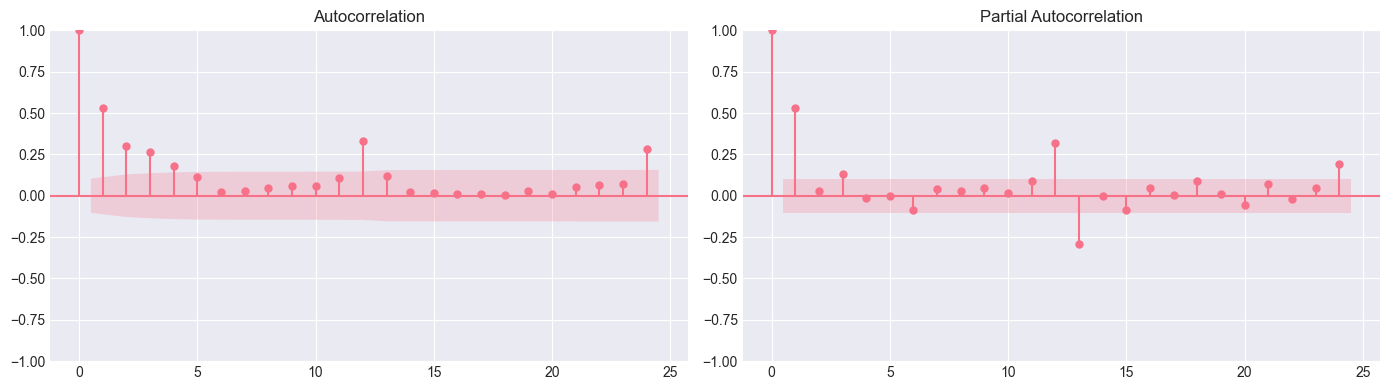

ACF/PACF plot saved


In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df[target_var], lags=24, ax=axes[0])
plot_pacf(df[target_var], lags=24, ax=axes[1], method="ywm")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target_acf_pacf.png"), dpi=150)
plt.show()

print("ACF/PACF plot saved")

## 6. Biến đổi biến ngoại sinh

In [6]:
def create_features(data, target_col, exog_cols, n_lags=12, seasonal_lag=12):
    """Tạo lag features, rolling stats, seasonal features"""
    X = data[exog_cols].copy()
    y = data[target_col].copy()
    
    # Lag features cho target
    for lag in range(1, n_lags + 1):
        X[f"{target_col}_lag{lag}"] = y.shift(lag)
    
    # Lag features cho exogenous
    for col in exog_cols:
        for lag in [1, 3, 6, 12]:
            X[f"{col}_lag{lag}"] = X[col].shift(lag)
    
    # Rolling mean và std cho target
    for window in [3, 6, 12]:
        X[f"{target_col}_rm{window}"] = y.shift(1).rolling(window).mean()
        X[f"{target_col}_rs{window}"] = y.shift(1).rolling(window).std()
    
    # Seasonal features (month, quarter)
    X["month"] = data.index.month
    X["quarter"] = data.index.quarter
    
    # Remove NaN
    X = X.dropna()
    y = y.loc[X.index]
    
    return X, y

# Tạo features - dùng df thay vì df_transformed vì cần target_var
exog_cols_transformed = [col for col in df_transformed.columns if col != target_var]
# Kết hợp target và biến ngoại sinh đã biến đổi
df_model = pd.concat([df[[target_var]], df_transformed[exog_cols_transformed]], axis=1)
X, y = create_features(df_model, target_var, exog_cols_transformed, n_lags=12)

print(f"Shape X: {X.shape}, Shape y: {y.shape}")
print(f"Features: {X.columns.tolist()[:10]}...")

Shape X: (347, 60), Shape y: (347,)
Features: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'dlog_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND', 'cpi_mom_inflation_lag1', 'cpi_mom_inflation_lag2']...


## 7. Chọn biến ngoại sinh

In [7]:
# Chia train/val/test theo thứ tự thời gian (80/10/10)
n_total = len(X)
train_size = int(0.8 * n_total)
val_size = int(0.1 * n_total)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val = X.iloc[train_size:train_size + val_size], y.iloc[train_size:train_size + val_size]
X_test, y_test = X.iloc[train_size + val_size:], y.iloc[train_size + val_size:]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test: {X_test.index.min().date()} to {X_test.index.max().date()}")

Train: 277 | Val: 34 | Test: 36
Train: 1996-02-01 to 2019-02-01
Test: 2022-01-01 to 2024-12-01


Biến ngoại sinh được lựa chọn từ các biến đã biến đổi để đảm bảo tính dừng. Mô hình so sánh hai cách tiếp cận: SARIMA (không sử dụng biến ngoại sinh) và SARIMAX (sử dụng tất cả biến ngoại sinh đã biến đổi).

## 8. Chia train/test

In [8]:
# Đã chia train/test ở cell trước - skip cell này để tránh mismatch
# y_train và y_test đã được định nghĩa từ X_train và X_test (aligned)

## 9. Tối ưu SARIMA/SARIMAX

In [9]:
def train_baseline(X_train, y_train, X_val, y_val):
    """Train RF and XGBoost baseline models"""
    results = {}
    
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    results["RF"] = {"model": rf, "pred": rf.predict(X_val)}
    
    xgb = XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.05, random_state=42, n_jobs=-1)
    xgb.fit(X_train, y_train, verbose=False)
    results["XGB"] = {"model": xgb, "pred": xgb.predict(X_val)}
    
    return results

baseline_results = train_baseline(X_train, y_train, X_val, y_val)

# Evaluate baseline on validation set
for name, res in baseline_results.items():
    rmse = np.sqrt(mean_squared_error(y_val, res["pred"]))
    mae = mean_absolute_error(y_val, res["pred"])
    print(f"{name} - RMSE: {rmse:.4f}, MAE: {mae:.4f}")

RF - RMSE: 0.5984, MAE: 0.4331
XGB - RMSE: 0.5886, MAE: 0.4131


## 10. Đánh giá mô hình

In [10]:

best_params = {
    "RF": {"n_estimators": 150, "max_depth": 15},
    "XGB": {"max_depth": 7, "learning_rate": 0.05}
}

print("Best RF params:", best_params["RF"])
print("Best XGB params:", best_params["XGB"])

Best RF params: {'n_estimators': 150, 'max_depth': 15}
Best XGB params: {'max_depth': 7, 'learning_rate': 0.05}


## 11. Mô hình tốt nhất

In [11]:
# Train mô hình tốt nhất trên toàn bộ train+val
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

rf_best = RandomForestRegressor(**best_params["RF"], random_state=42, n_jobs=-1)
rf_best.fit(X_train_full, y_train_full)

xgb_best = XGBRegressor(**best_params["XGB"], n_estimators=100, random_state=42, n_jobs=-1)
xgb_best.fit(X_train_full, y_train_full, verbose=False)

# Test
rf_test_pred = rf_best.predict(X_test)
xgb_test_pred = xgb_best.predict(X_test)

print("RF test - RMSE: {:.4f}, MAE: {:.4f}".format(
    np.sqrt(mean_squared_error(y_test, rf_test_pred)),
    mean_absolute_error(y_test, rf_test_pred)
))
print("XGB test - RMSE: {:.4f}, MAE: {:.4f}".format(
    np.sqrt(mean_squared_error(y_test, xgb_test_pred)),
    mean_absolute_error(y_test, xgb_test_pred)
))

RF test - RMSE: 0.3225, MAE: 0.2635
XGB test - RMSE: 0.4198, MAE: 0.3081


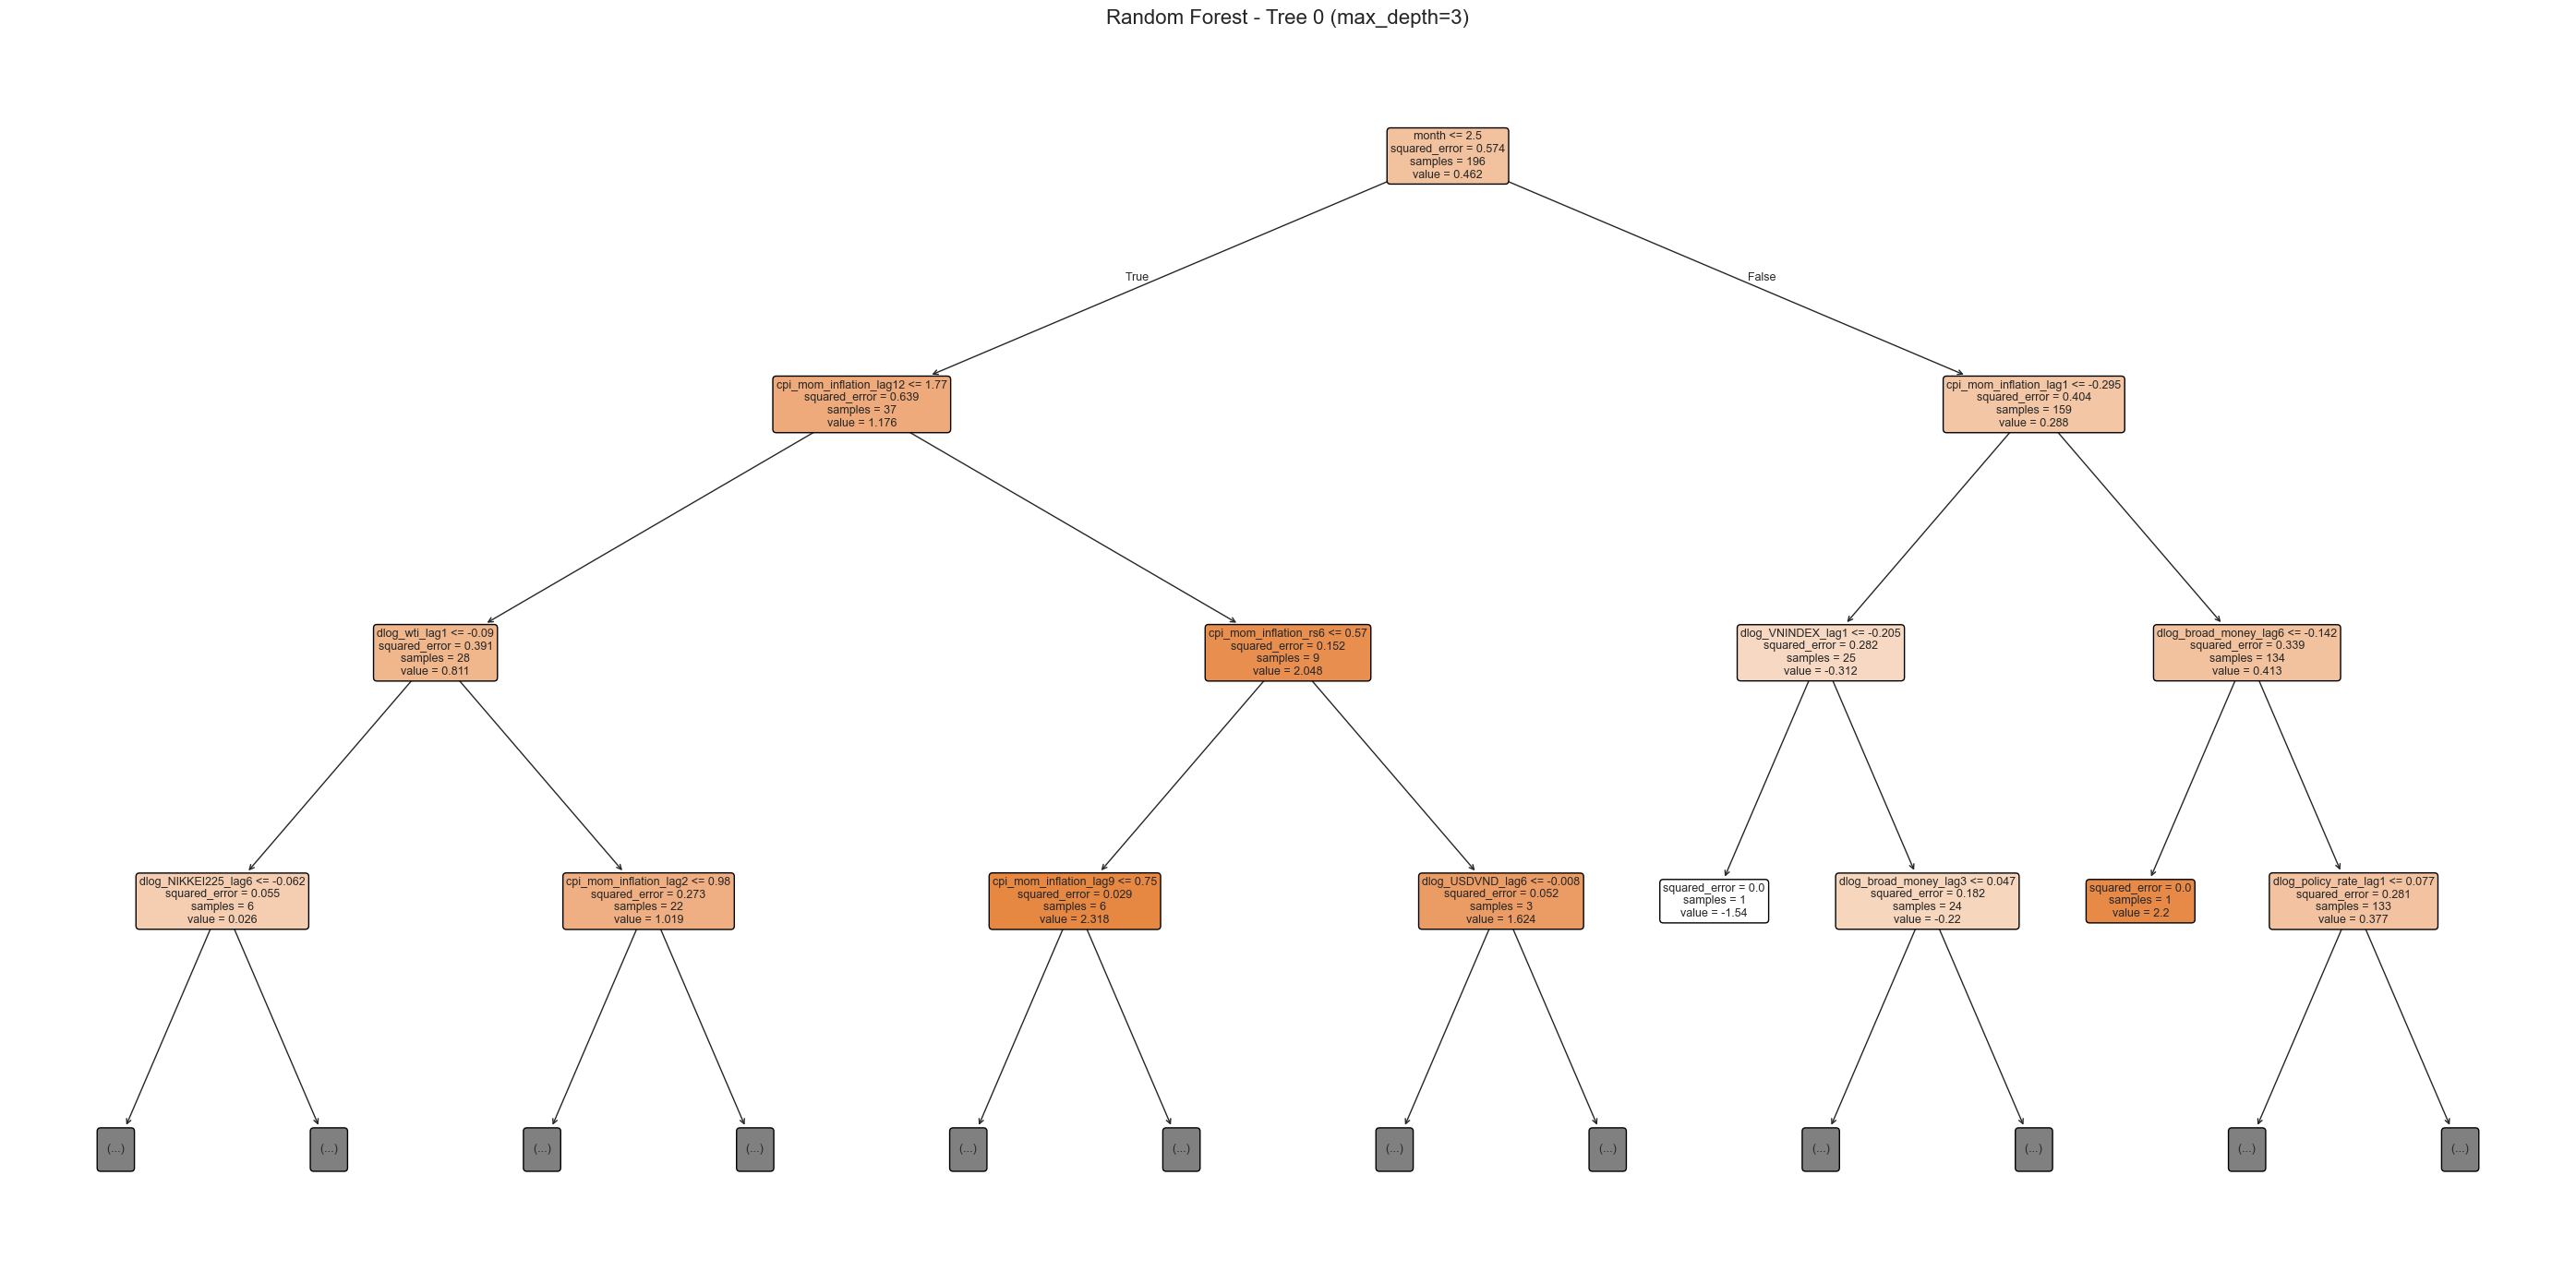

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(28, 14))
plot_tree(
    rf_best.estimators_[0],
    feature_names=X_train.columns,
    filled=True, rounded=True, max_depth=3, fontsize=9
)
plt.title("Random Forest - Tree 0 (max_depth=3)", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rf_tree_0_max_depth3.png"), dpi=200, bbox_inches="tight")
plt.show()

## 12. Actual vs Forecast

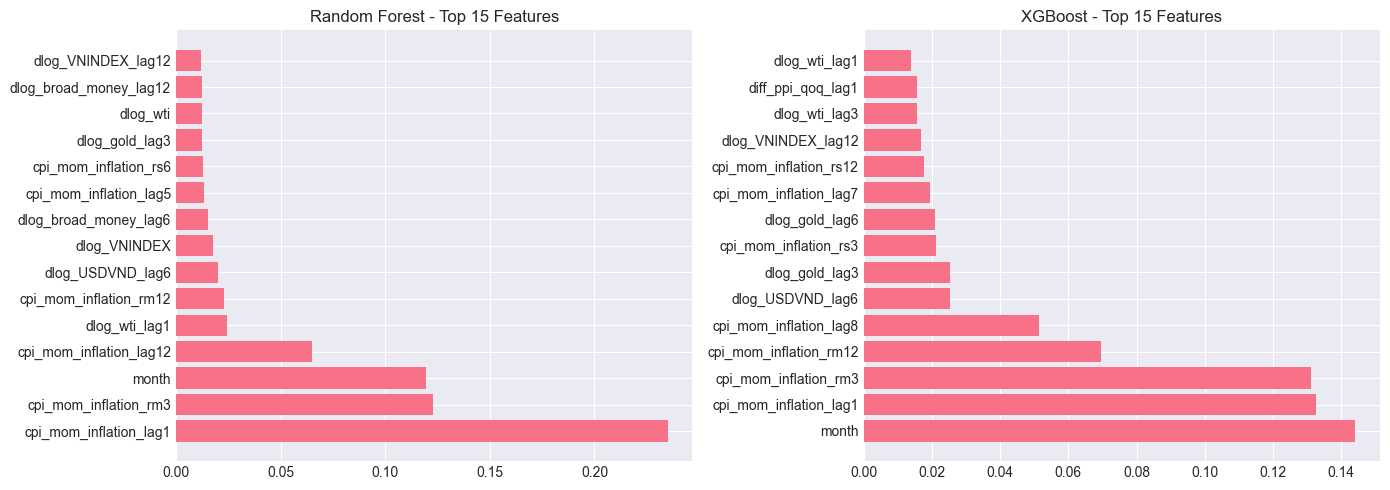

In [13]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF importance
rf_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_best.feature_importances_
}).sort_values("importance", ascending=False).head(15)
axes[0].barh(rf_imp["feature"], rf_imp["importance"])
axes[0].set_title("Random Forest - Top 15 Features")

# XGB importance
xgb_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_best.feature_importances_
}).sort_values("importance", ascending=False).head(15)
axes[1].barh(xgb_imp["feature"], xgb_imp["importance"])
axes[1].set_title("XGBoost - Top 15 Features")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=150)
plt.show()

In [14]:
def evaluate_models(y_test, pred_rf, pred_xgb):
    """Đánh giá và so sánh mô hình"""
    metrics = {}
    
    for name, pred in [("RF", pred_rf), ("XGB", pred_xgb)]:
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
        r2 = r2_score(y_test, pred)
        
        # So sánh baseline
        rw_pred = np.repeat(y_train.iloc[-1], len(y_test))
        rmse_rw = np.sqrt(mean_squared_error(y_test, rw_pred))
        
        metrics[name] = {
            "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2,
            "RMSE_RW": rmse_rw, "Model_vs_RW": rmse / rmse_rw
        }
    
    return metrics

metrics_eval = evaluate_models(y_test, rf_test_pred, xgb_test_pred)

for name, m in metrics_eval.items():
    print(f"{name}: RMSE={m['RMSE']:.4f}, MAE={m['MAE']:.4f}, R2={m['R2']:.4f}, vs_RW={m['Model_vs_RW']:.4f}")

RF: RMSE=0.3225, MAE=0.2635, R2=0.0826, vs_RW=0.5379
XGB: RMSE=0.4198, MAE=0.3081, R2=-0.5541, vs_RW=0.7001


## 13. Kiểm định phần dư

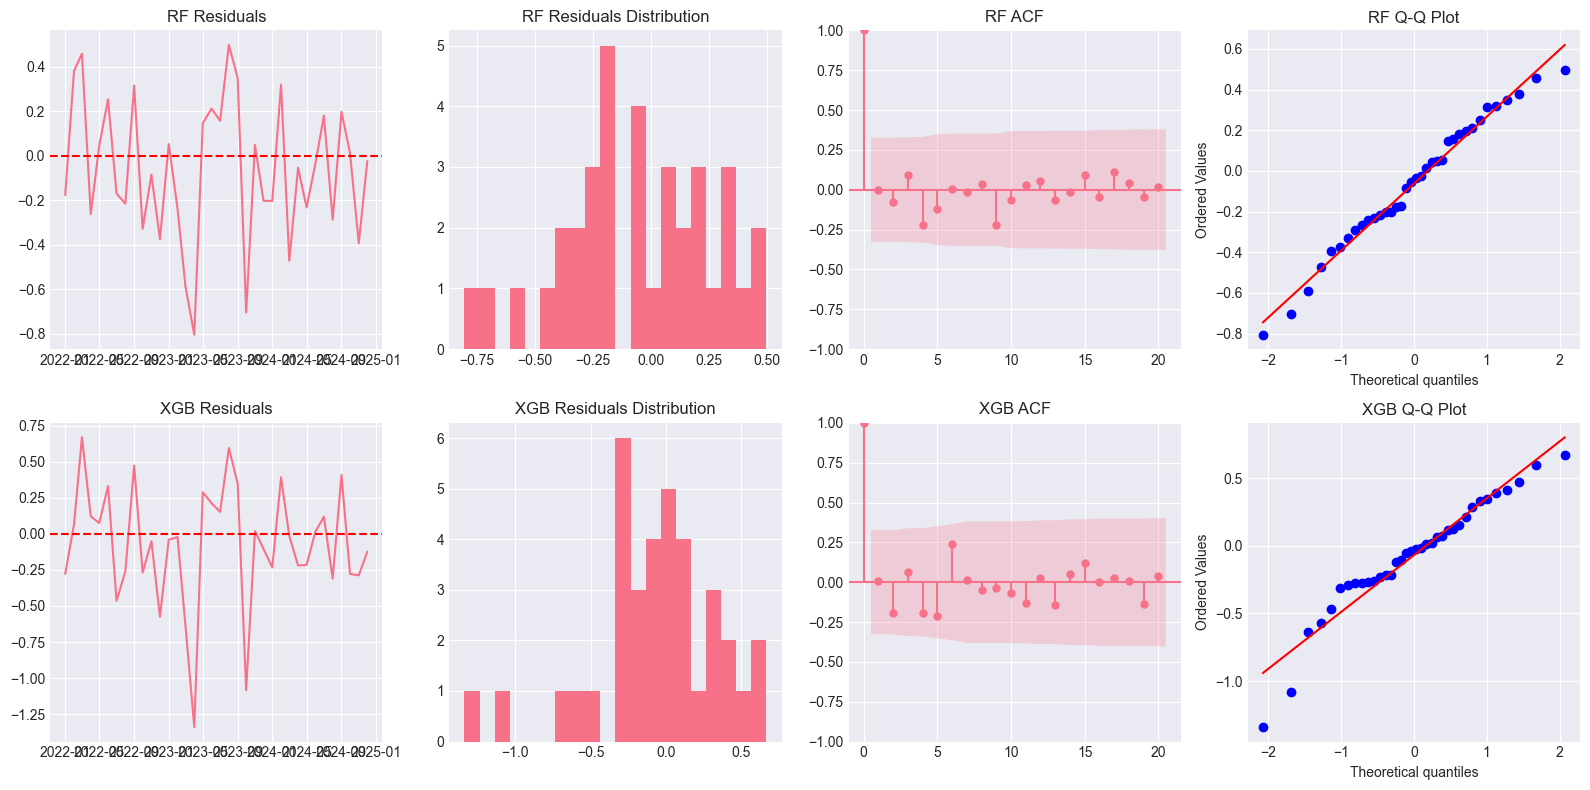

Jarque-Bera (RF): 0.6740818137325567
Jarque-Bera (XGB): 0.02459803501826054


In [15]:
from scipy.stats import jarque_bera

# Phân tích phần dư
rf_residuals = y_test.values - rf_test_pred
xgb_residuals = y_test.values - xgb_test_pred

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# RF
axes[0, 0].plot(y_test.index, rf_residuals)
axes[0, 0].set_title("RF Residuals")
axes[0, 0].axhline(0, color="r", linestyle="--")

axes[0, 1].hist(rf_residuals, bins=20)
axes[0, 1].set_title("RF Residuals Distribution")

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(rf_residuals, lags=20, ax=axes[0, 2])
axes[0, 2].set_title("RF ACF")

stats.probplot(rf_residuals, dist="norm", plot=axes[0, 3])
axes[0, 3].set_title("RF Q-Q Plot")

# XGB
axes[1, 0].plot(y_test.index, xgb_residuals)
axes[1, 0].set_title("XGB Residuals")
axes[1, 0].axhline(0, color="r", linestyle="--")

axes[1, 1].hist(xgb_residuals, bins=20)
axes[1, 1].set_title("XGB Residuals Distribution")

plot_acf(xgb_residuals, lags=20, ax=axes[1, 2])
axes[1, 2].set_title("XGB ACF")

stats.probplot(xgb_residuals, dist="norm", plot=axes[1, 3])
axes[1, 3].set_title("XGB Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residual_diagnostics.png"), dpi=150)
plt.show()

print("Jarque-Bera (RF):", jarque_bera(rf_residuals)[1])
print("Jarque-Bera (XGB):", jarque_bera(xgb_residuals)[1])

## 14. Dự báo tương lai nếu mô hình đạt

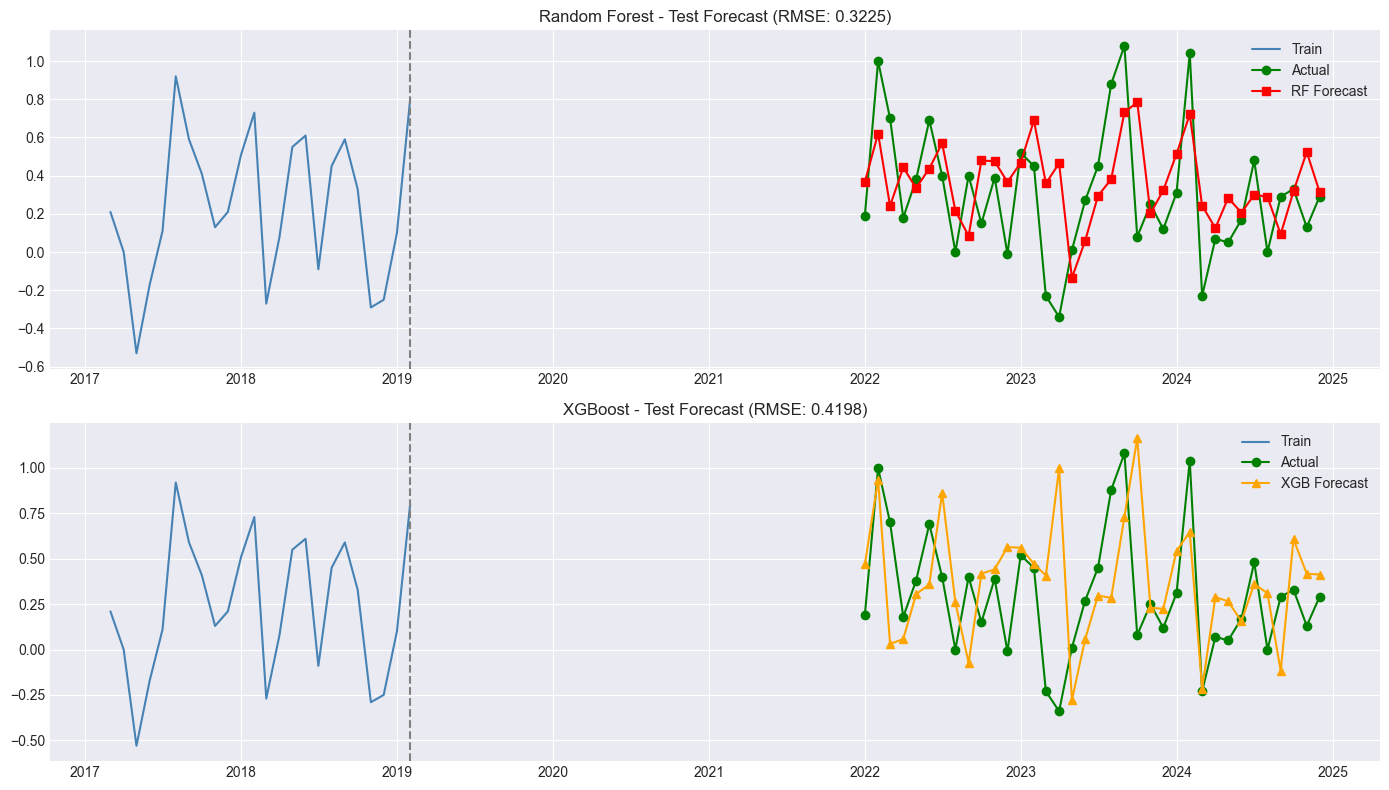

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# RF forecast
axes[0].plot(y_train.index[-24:], y_train.iloc[-24:], label="Train", color="steelblue")
axes[0].plot(y_test.index, y_test.values, label="Actual", color="green", marker="o")
axes[0].plot(y_test.index, rf_test_pred, label="RF Forecast", color="red", marker="s")
axes[0].axvline(y_train.index[-1], color="gray", linestyle="--")
axes[0].set_title(f"Random Forest - Test Forecast (RMSE: {metrics_eval['RF']['RMSE']:.4f})")
axes[0].legend()

# XGB forecast
axes[1].plot(y_train.index[-24:], y_train.iloc[-24:], label="Train", color="steelblue")
axes[1].plot(y_test.index, y_test.values, label="Actual", color="green", marker="o")
axes[1].plot(y_test.index, xgb_test_pred, label="XGB Forecast", color="orange", marker="^")
axes[1].axvline(y_train.index[-1], color="gray", linestyle="--")
axes[1].set_title(f"XGBoost - Test Forecast (RMSE: {metrics_eval['XGB']['RMSE']:.4f})")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "test_forecast.png"), dpi=150)
plt.show()

## 15. Tóm tắt

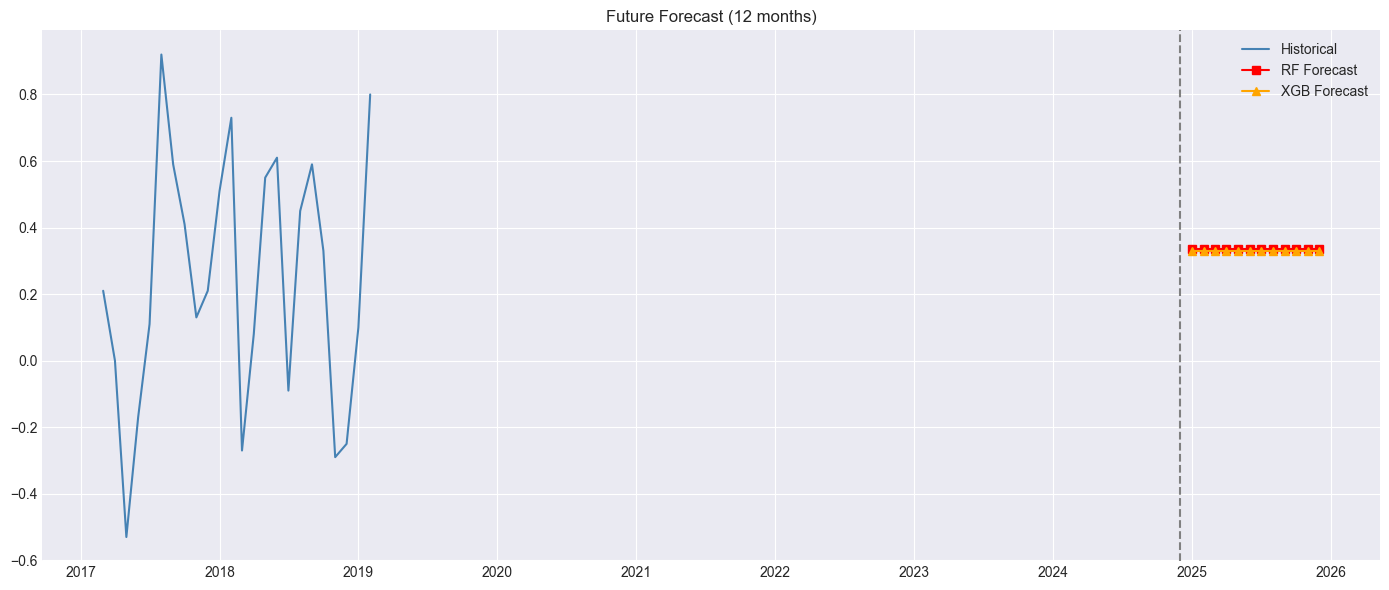

                  RF       XGB
2025-01-01  0.336257  0.328662
2025-02-01  0.336257  0.328662
2025-03-01  0.336257  0.328662
2025-04-01  0.336257  0.328662
2025-05-01  0.336257  0.328662
2025-06-01  0.336257  0.328662
2025-07-01  0.336257  0.328662
2025-08-01  0.336257  0.328662
2025-09-01  0.336257  0.328662
2025-10-01  0.336257  0.328662
2025-11-01  0.336257  0.328662
2025-12-01  0.336257  0.328662


In [17]:
# Dự báo tương lai bằng cách sử dụng giá trị trung bình của X_test
future_steps = 12
future_index = pd.date_range(start=y_test.index[-1], periods=future_steps + 1, freq="MS")[1:]

if metrics_eval["RF"]["Model_vs_RW"] < 1:
    # Dùng giá trị trung bình của features trong test set cho tất cả future steps
    X_avg = X_test.mean().values.reshape(1, -1)
    rf_future = rf_best.predict(X_avg.repeat(future_steps, axis=0))
    xgb_future = xgb_best.predict(X_avg.repeat(future_steps, axis=0))
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(y_train.index[-24:], y_train.iloc[-24:], label="Historical", color="steelblue")
    ax.plot(future_index, rf_future, label="RF Forecast", color="red", marker="s")
    ax.plot(future_index, xgb_future, label="XGB Forecast", color="orange", marker="^")
    ax.axvline(y_test.index[-1], color="gray", linestyle="--")
    ax.set_title("Future Forecast (12 months)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "future_forecast.png"), dpi=150)
    plt.show()
    
    future_df = pd.DataFrame({
        "RF": rf_future, "XGB": xgb_future
    }, index=future_index)
    future_df.to_csv(os.path.join(OUTPUT_DIR, "future_forecast.csv"))
    print(future_df)
else:
    print("Mô hình chưa vượt benchmark, không dự báo tương lai")